# EDA de descuentos en Applebee’s · abril–agosto de 2026

**Objetivo:** comprender los descuentos habituales y generar señales para revisión.
Una anomalía no demuestra fraude; el importe descontado no es pérdida demostrada.
No hay etiquetas de fraude ni políticas de descuento disponibles.

El notebook se ejecuta en tu entorno con tus archivos. Procesa JSON por lotes,
consulta Parquet con DuckDB y lleva únicamente agregados/muestras a pandas.
Los reportes quedan en `outputs/`, excluido de Git. No se incorporan nombres ni
fechas de nacimiento de empleados a las tablas analíticas.

Ejecuta las celdas en orden. Instala primero `requirements.txt` y selecciona ese
entorno como kernel. En Databricks, configura rutas del sistema de archivos
accesibles desde Python (por ejemplo, `/Volumes/...`) y añade el repositorio a `sys.path`.
Esta versión usa DuckDB en el proceso del notebook, sin requerir Spark.


In [4]:
%pip install duckdb ijson pyarrow
%pip install -r "c:\Users\shdez\Databricks-Applebees_anomaly_detection\requirements.txt"

   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   -------- ------------------------------- 2.9/13.2 MB 18.6 MB/s eta 0:00:01
   --------------------- ------------------ 7.1/13.2 MB 19.0 MB/s eta 0:00:01
   ----------------------------------- ---- 11.8/13.2 MB 20.0 MB/s eta 0:00:01
   ---------------------------------------- 13.2/13.2 MB 19.2 MB/s  0:00:00

   -------------------- ------------------- 1/2 [duckdb]
   ---------------------------------------- 2/2 [duckdb]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ------------ --------------------------- 3.4/11.3 MB 18.3 MB/s eta 0:00:01
   ------------------------- -------------- 7.1/11.3 MB 19.0 MB/s eta 0:00:01
   ------------------------------------- -- 10.5/11.3 MB 17.7 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 14.2 MB/s  0:00:00

   ---------- ----------------------------- 2/8 [narwhals]
   ---------- ----------------------------- 2/8 [narwhals]
   ---------- ----------------------------- 2/8 [narwhals]
   ------------------------- -------------- 5/8 [pytest]
   ------------------------- -------------- 5/8 [pytest]
   ------------------------------ --------- 6/8 [formulaic]
   ----------------------------------- ---- 7/8 [statsmodels]
   ----------------------------------- ---- 7/8 [statsmodels]
   ----------------------------------- ---- 7/8 [statsmodels]
   ----------------------------------- ---- 7/8 [statsmodels]
   ----------------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from pathlib import Path
import sys, os, json

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "applebees_eda").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Abre el notebook desde el repositorio o añade su ruta a sys.path.")
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from applebees_eda import Config, ingest, open_database, prepare_facts, quality_report
from applebees_eda.pipeline import monetary_gate
from applebees_eda.analysis import (
    baseline, discount_types, check_sample, seller_contexts, actor_roles,
    employee_manager_pairs, weekly_trends, associations, explore_anomalies,
    review_checks, export_reports,
)

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 25)


## Configuración

Edita las rutas. Los cuatro catálogos se esperan como arrays `[{...}]`; un catálogo
ausente se reporta y permite continuar el análisis de cuentas. `JobID` es una
lista; `PrimaryJobID` conserva exactamente esa capitalización.

**Convenciones monetarias:** empieza con `unresolved`. Después de revisar la
pregunta 1, selecciona `price_mode` (`line` o `unit`), `discount_mode`
(`records_sum`, `price_difference` o `price_difference_plus_check`) y
`gratuity_mode` (`add`, `subtract` o `ignore`) y vuelve a ejecutar desde la
preparación de hechos. La mejor conciliación es evidencia, no prueba de semántica:
varias hipótesis pueden coincidir cuando Quantity=1 o no hay descuentos.

- `records_sum`: suma de Amount en registros de descuento de cuenta y artículo.
- `price_difference`: diferencia entre GrossPrice y SoldPrice, ajustada según precio.
- `price_difference_plus_check`: esa diferencia más descuentos registrados de cuenta.

Cada opción debe contrastarse con casos con cantidad distinta de 1, descuentos
en ambos niveles y ajustes/propinas. No se calcula un total económico validado
automáticamente al escoger la hipótesis con más coincidencias.


In [7]:
RAW = Path(os.environ.get("APPLEBEES_RAW", str(ROOT / "data" / "raw")))
config = Config(
    checks=(os.environ.get("APPLEBEES_CHECKS", str(RAW / "checks*.json")),),
    catalogs={
        "revenue_centers": str(RAW / "revenueCenters.json"),
        "locations": str(RAW / "locations.json"),
        "items": str(RAW / "items.json"),
        "employees": str(RAW / "employees.json"),
    },
    output_dir=Path(os.environ.get("APPLEBEES_OUTPUT", str(ROOT / "outputs" / "eda"))),
    start_date="2026-04-01", end_date="2026-08-31",
    batch_checks=500, memory_limit="2GB",
    price_mode=os.environ.get("APPLEBEES_PRICE_MODE", "unresolved"),
    discount_mode=os.environ.get("APPLEBEES_DISCOUNT_MODE", "unresolved"),
    gratuity_mode=os.environ.get("APPLEBEES_GRATUITY_MODE", "unresolved"),
    money_tolerance=0.02, minimum_reconciliation=0.95,
    minimum_peer_checks=30, minimum_peer_employees=3,
    minimum_training_rows=50, minimum_training_sellers=5,
    random_state=42,
)
# Para archivos dentro de subcarpetas:
# config.checks = (str(RAW / "checks" / "**" / "*.json"),)
# Para JSON {"Checks": [...]}: config.json_prefixes = {"checks": "Checks.item"}
# .jsonl/.ndjson se reconocen por extensión; no se convierten a arrays en memoria.
# Si el nombre del archivo de revenueCenters es diferente, cambia su ruta arriba.
print("Período:", config.start_date, "a", config.end_date)
print("Destino:", config.output_dir)


Período: 2026-04-01 a 2026-08-31
Destino: c:\Users\shdez\Databricks-Applebees_anomaly_detection\outputs\eda


In [10]:
RAW = Path(os.environ.get("APPLEBEES_RAW", r"C:\Shdezg2000\Datasets\Applebee's"))
DIMS = RAW / "dimensions" / "dimensions"
FACTS = RAW / "facts" / "facts" / "checks" / "brand=rmh"

config = Config(
    checks=(os.environ.get("APPLEBEES_CHECKS", str(FACTS / "dt=*" / "checks.json")),),
    catalogs={
        "revenue_centers": str(DIMS / "revenue_centers" / "revenueCenters.json"),
        "locations":       str(DIMS / "locations" / "locations.json"),
        "items":           str(DIMS / "items" / "items.json"),
        "employees":       str(DIMS / "employees" / "employees.json"),
    },
    output_dir=Path(os.environ.get("APPLEBEES_OUTPUT", str(ROOT / "outputs" / "eda"))),
    start_date="2026-04-28", end_date="2026-08-20",
    batch_checks=2000, memory_limit="4GB",
    price_mode="unresolved",
    discount_mode="unresolved",
    gratuity_mode="unresolved",
    money_tolerance=0.05, minimum_reconciliation=0.95,
    minimum_peer_checks=30, minimum_peer_employees=3,
    minimum_training_rows=50, minimum_training_sellers=5,
    random_state=42,
)
# Si el patrón dt=* no encuentra nada, usa este (el notebook lo documenta):
# config.checks = (str(FACTS / "**" / "*.json"),)
print("Período:", config.start_date, "a", config.end_date)
print("Destino:", config.output_dir)

Período: 2026-04-28 a 2026-08-20
Destino: c:\Users\shdez\Databricks-Applebees_anomaly_detection\notebooks\outputs\eda


## Carga reproducible

La memoria de ingestión depende del lote y del tamaño del mayor check, no de los
10 GB completos. Parquet se comprime con Zstandard. DuckDB dispone de una carpeta
temporal para operaciones que excedan su memoria de trabajo; reserva espacio en disco.
El límite de DuckDB no limita pandas ni todo el proceso Python.

Un snapshot existente se reutiliza; no se sobrescribe. Cuando cambien archivos,
catálogos o prefijos JSON, usa otro `output_dir`. Los identificadores de cuenta
duplicados o inválidos se conservan para diagnóstico y se excluyen del EDA.
También se excluyen cuentas con arrays faltantes/nulos: ausencia de datos no
equivale automáticamente a ausencia de descuentos o pagos.


In [11]:
snapshot = config.output_dir / "parquet"
if not snapshot.exists():
    manifest = ingest(config)
else:
    manifest = json.loads((snapshot / "manifest.json").read_text(encoding="utf-8"))
print("Registros cargados:", manifest["counts"])
print("Catálogos:", manifest["catalogs"])
print("Arrays faltantes/nulos:", manifest["issues"])
if "con" in globals():
    con.close()
con = open_database(config)
prepare_facts(con, config)

def finish_plot(ax, title, x, y, note=""):
    ax.set(title=title, xlabel=x, ylabel=y)
    ax.figure.text(.01, .01, f"Fuente: JSON configurados · {config.start_date} a {config.end_date}. {note}",
                   fontsize=8, wrap=True)
    ax.figure.tight_layout(rect=(0, .09, 1, 1))
    display(ax.figure)
    plt.close(ax.figure)


Registros cargados: {'revenue_centers': 23, 'locations': 185, 'items': 16697, 'employees': 156975, 'employee_jobs': 670557, 'checks': 2142846, 'sold_items': 28558925, 'discounts': 516690, 'payments': 2232092, 'voids': 178303, 'taxes': 2569636}
Catálogos: {'revenue_centers': 'loaded', 'locations': 'loaded', 'items': 'loaded', 'employees': 'loaded'}
Arrays faltantes/nulos: {}


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## 1. ¿Los datos permiten medir correctamente los descuentos?

**Métodos:** conteos, cobertura, referencias y conciliación con tolerancia de 0.02
unidades monetarias. La moneda no está identificada en el esquema: no sumar entre
monedas si posteriormente se descubre que las localizaciones utilizan monedas distintas.

Los catálogos con Id duplicados se marcan ambiguos y no aportan atributos al cruce.
`Deleted=true` se conserva; `Borrowed` y diferencias de localización son contexto,
no reglas de fraude. `HomeLocationId=0` necesita definición del proveedor.
La relación de SalesCategoryId con categorías del check se evalúa, no se asume.

Los horarios civiles originales se conservan. Se convierten a UTC únicamente con
zona válida o un offset explícito. Horas ambiguas/inexistentes por horario de verano
se reportan y no se inventa su instante UTC. BusinessDate sigue siendo fecha operativa.


In [12]:
quality = quality_report(con, config)
for name in ["selection", "catalogs", "references", "check_issues", "time_status", "category_mapping"]:
    print("\n", name)
    display(quality[name])
display(quality["coverage"].head(10))
coverage = quality["coverage"]
expected_days = pd.date_range(config.start_date, config.end_date)
observed_days = pd.DatetimeIndex(coverage.business_day)
print("Días sin cuentas en los archivos:", len(expected_days.difference(observed_days)))
print("La ausencia de cuentas no demuestra cierre ni inactividad: puede faltar un archivo.")



 selection


,selection_status,checks
0,included,2142846



 catalogs


,catalog,rows,missing_id,distinct_ids,ambiguous_rows
0,locations,185,0,185,0
1,employees,156975,0,156975,0
2,items,16697,0,16697,0
3,revenue_centers,23,0,23,0



 references


...

,field,status,checks
0,open,valid,2142846
1,close,valid,2142846



 category_mapping


,matched_lines,matches_subcategory,matches_major_category,plu_mismatches
0,28558925,28558925,0,0


,business_day,checks,locations,discount_incidence
0,2026-04-28,15467,126,0.123165
1,2026-04-29,16392,126,0.124146
2,2026-04-30,18312,127,0.126201
3,2026-05-01,25263,127,0.114040
4,2026-05-02,24268,127,0.115213
5,2026-05-03,19668,127,0.116890
6,2026-05-04,15409,127,0.138361
7,2026-05-05,15620,127,0.125032
8,2026-05-06,16445,127,0.129401
9,2026-05-07,17650,127,0.124136


Días sin cuentas en los archivos: 0
La ausencia de cuentas no demuestra cierre ni inactividad: puede faltar un archivo.


In [13]:
display(quality["reconciliation"])
amounts_ready, money_message = monetary_gate(con, config)
print(money_message)
print("Controles de conservación: una fila por cuenta incluida e importes registrados sin cambios después de cruces.")
display(con.execute("""SELECT count(*) included_checks,
    count(*) FILTER (WHERE money_eligible) money_eligible_checks,
    count(*) FILTER (WHERE seller_id IS NULL) checks_without_unique_seller FROM facts""").fetchdf())


,price_mode,discount_mode,gratuity_mode,n,match_fraction,median_abs_residual,p95_abs_residual,quantity_subset_n,quantity_subset_match,discounted_subset_n,discounted_subset_match
7,line,price_difference_plus_check,subtract,2127874.0,0.999975,0.000000e+00,1.421085e-14,19703.0,0.999797,266025.0,0.999876
1,line,records_sum,subtract,2127874.0,0.999974,0.000000e+00,1.421085e-14,19703.0,0.999797,266025.0,0.999868
16,unit,price_difference_plus_check,subtract,2127874.0,0.990804,0.000000e+00,1.421085e-14,19703.0,0.009389,266025.0,0.994707
10,unit,records_sum,subtract,2127874.0,0.990776,0.000000e+00,1.421085e-14,19703.0,0.006446,266025.0,0.994482
4,line,price_difference,subtract,2127874.0,0.900177,0.000000e+00,7.490000e+00,19703.0,0.946455,266025.0,0.201616
13,unit,price_difference,subtract,2127874.0,0.891511,0.000000e+00,8.000000e+00,19703.0,0.010608,266025.0,0.200489
8,line,price_difference_plus_check,ignore,2127874.0,0.516618,1.421085e-14,1.500000e+01,19703.0,0.371720,266025.0,0.665633
2,line,records_sum,ignore,2127874.0,0.516617,1.421085e-14,1.500000e+01,19703.0,0.371720,266025.0,0.665629
6,line,price_difference_plus_check,add,2127874.0,0.516583,1.421085e-14,3.000000e+01,19703.0,0.371720,266025.0,0.665607
0,line,records_sum,add,2127874.0,0.516583,1.421085e-14,3.000000e+01,19703.0,0.371720,266025.0,0.665603


Importes derivados pendientes: selecciona las convenciones después de revisar conciliación.
Controles de conservación: una fila por cuenta incluida e importes registrados sin cambios después de cruces.


,included_checks,money_eligible_checks,checks_without_unique_seller
0,2142846,0,11508


## 2. ¿Cuál es el comportamiento habitual?

Una cuenta tiene descuento observado si existe un registro de descuento con
Amount positivo; registros de importe cero se cuentan por separado. Las métricas
económicas solo se interpretan después de conciliar, sobre cuentas `money_eligible`.
Los importes de registros sin resolver se etiquetan como provisionales.

Revisa medianas, percentiles y distribución; un ranking por importe total también
refleja cuánto vende cada localización. El ejemplo no tiene una columna de total
de cuenta: el total debe reconstruirse y validarse.


,location_id,checks,discounted_checks,discount_rate,reconciled_checks,gross_sales_reconciled,discount_amount_reconciled,discount_to_gross,median_check_discount_ratio,p95_check_discount_ratio,cash_check_rate,void_check_rate
0,87,29245,3631.0,0.124158,0,NaN,NaN,NaN,NaN,NaN,0.183177,0.024654
1,198,28223,2817.0,0.099812,0,NaN,NaN,NaN,NaN,NaN,0.158098,0.027708
2,1,27135,2980.0,0.109821,0,NaN,NaN,NaN,NaN,NaN,0.187249,0.027713
3,170,26001,2842.0,0.109303,0,NaN,NaN,NaN,NaN,NaN,0.198800,0.017769
4,166,24051,2697.0,0.112137,0,NaN,NaN,NaN,NaN,NaN,0.186770,0.014469
5,82,23889,3562.0,0.149106,0,NaN,NaN,NaN,NaN,NaN,0.194190,0.029051
6,187,23656,3767.0,0.159241,0,NaN,NaN,NaN,NaN,NaN,0.182660,0.024814
7,5,23637,3436.0,0.145365,0,NaN,NaN,NaN,NaN,NaN,0.175107,0.031011
8,137,23507,3107.0,0.132173,0,NaN,NaN,NaN,NaN,NaN,0.124601,0.027864
9,9,23500,1994.0,0.084851,0,NaN,NaN,NaN,NaN,NaN,0.204681,0.021915


,revenue_center_id,checks,discounted_checks,discount_rate,reconciled_checks,gross_sales_reconciled,discount_amount_reconciled,discount_to_gross,median_check_discount_ratio,p95_check_discount_ratio,cash_check_rate,void_check_rate
0,1,1649922,234058.0,0.141860,0,NaN,NaN,NaN,NaN,NaN,0.229337,0.031964
1,11,197995,0.0,0.000000,0,NaN,NaN,NaN,NaN,NaN,0.000000,0.000010
2,4,138305,10102.0,0.073041,0,NaN,NaN,NaN,NaN,NaN,0.021749,0.001468
3,2,95357,23951.0,0.251172,0,NaN,NaN,NaN,NaN,NaN,0.299737,0.022411
4,12,47914,0.0,0.000000,0,NaN,NaN,NaN,NaN,NaN,0.000000,0.000042
5,20,7020,0.0,0.000000,0,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
6,25,2535,144.0,0.056805,0,NaN,NaN,NaN,NaN,NaN,0.000000,0.001972
7,21,1232,0.0,0.000000,0,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
8,24,1059,61.0,0.057602,0,NaN,NaN,NaN,NaN,NaN,0.000000,0.003777
9,7,644,104.0,0.161491,0,NaN,NaN,NaN,NaN,NaN,0.107143,0.021739


,location_id,discount_id,discount_name,level,records,checks,recorded_amount_provisional,positive_records,zero_records,negative_records
0,14,93,MILTARY 10,check,1668,1638,3733.19,1668,0,0
1,114,146,LRM10%,check,1569,1500,3867.52,1569,0,0
2,34,93,MILTARY 10,check,1272,1239,4871.44,1272,0,0
3,96,146,LRM10%,check,1064,1000,2726.50,1064,0,0
4,5,69,HOTEL %,check,996,967,5648.45,996,0,0
5,168,93,MILTARY 10,check,973,960,3696.89,973,0,0
6,144,93,MILTARY 10,check,979,950,3928.58,979,0,0
7,1,429,Marketing,item,1216,941,12377.40,1215,1,0
8,87,429,Marketing,item,1196,871,12141.96,1195,1,0
9,20,520,EMP 50,check,846,792,6152.11,846,0,0


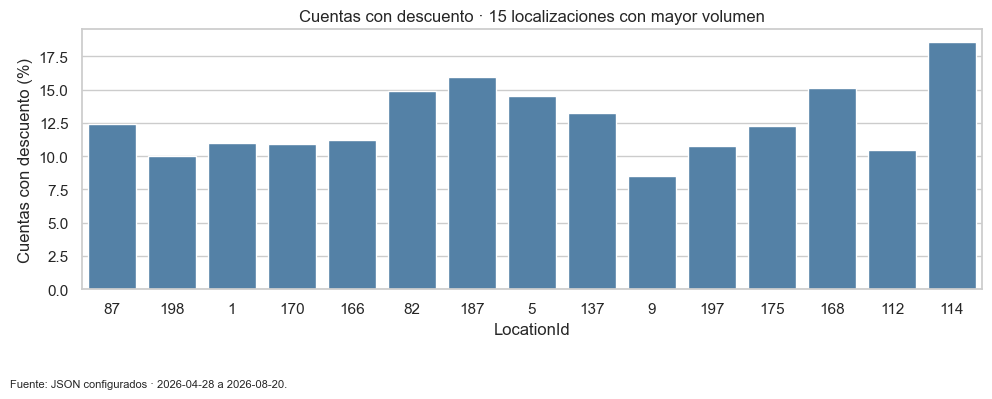

Distribución monetaria pendiente de conciliación. Las tasas de frecuencia sí están disponibles.


In [14]:
by_location = baseline(con, "location_id")
by_center = baseline(con, "revenue_center_id")
types = discount_types(con)
display(by_location.head(20))
display(by_center)
display(types.head(20))
if not by_location.empty:
    plot = by_location.nlargest(15, "checks").copy()
    plot["rate_pct"] = 100*plot.discount_rate
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.barplot(data=plot, x="location_id", y="rate_pct", color="steelblue", errorbar=None, ax=ax)
    finish_plot(ax, "Cuentas con descuento · 15 localizaciones con mayor volumen", "LocationId", "Cuentas con descuento (%)")
sample = check_sample(con, seed=config.random_state, monetary=amounts_ready)
if amounts_ready and not sample.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(sample.discount_ratio*100, bins=30, ax=ax)
    finish_plot(ax, "Distribución del porcentaje descontado por cuenta", "Descuento / venta bruta (%)", "Cuentas (conteo)",
                f"Muestra determinista de hasta 10,000 cuentas conciliadas; n={len(sample)}.")
    fig, ax = plt.subplots(figsize=(9, 4))
    top_locations = by_location.nlargest(8, "reconciled_checks").location_id
    subset = sample[sample.location_id.isin(top_locations)].copy()
    if not subset.empty:
        subset["ratio_pct"] = subset.discount_ratio*100
        sns.boxplot(data=subset,x="location_id",y="ratio_pct",ax=ax)
        finish_plot(ax,"Porcentaje descontado por cuenta y localización","LocationId","Descuento / venta bruta (%)","Muestra de cuentas conciliadas.")
    else:
        plt.close(fig)
else:
    print("Distribución monetaria pendiente de conciliación. Las tasas de frecuencia sí están disponibles.")


## 3. ¿Qué empleados se apartan de compañeros comparables?

La unidad es vendedor × localización × centro de ingresos × franja de apertura.
El vendedor se obtiene de ItemsSold.EmployeeId únicamente si todos los artículos
tienen un mismo empleado identificado. Las cuentas de varios vendedores se
reportan aparte; el EmployeeId del pago no se usa como propietario de la venta.

**Métodos:** tasa de cuentas con descuento, intervalos de Wilson al 95%, diferencia
frente a la mediana de los demás empleados y percentil entre pares. Para comparar
se exigen 30 cuentas por empleado/contexto y al menos tres compañeros elegibles.
Son umbrales exploratorios configurables, no reglas de fraude. Wilson supone
ensayos independientes; las cuentas pueden estar correlacionadas por día/turno,
por lo que el intervalo se usa como referencia descriptiva, no como prueba formal.


,location_id,revenue_center_id,time_band,seller_id,checks,discounted_checks,reconciled_checks,gross_sales_reconciled,discount_amount_reconciled,discount_to_gross,void_checks,cash_checks,seller_deleted,seller_borrowed,discount_rate,wilson_low,wilson_high,limited_sample,peer_count,peer_median_rate,peer_percentile,robust_rate_distance,rate_excess,review_signal
1439,87,1,11-15,156136,41,40.0,0,NaN,NaN,NaN,1.0,0.0,False,False,0.975610,0.874049,0.995681,False,22,0.159579,1.000000,6.370773,0.816031,True
12647,87,1,11-15,156179,71,65.0,0,NaN,NaN,NaN,5.0,0.0,False,False,0.915493,0.827640,0.960693,False,22,0.159579,0.954545,5.901440,0.755914,True
2995,94,2,21-23,155181,32,28.0,0,NaN,NaN,NaN,0.0,3.0,False,False,0.875000,0.719317,0.950299,False,3,0.142857,1.000000,50.987210,0.732143,True
7119,87,1,16-20,156179,51,44.0,0,NaN,NaN,NaN,2.0,0.0,False,False,0.862745,0.742783,0.931889,False,25,0.149068,1.000000,27.353010,0.713677,True
2152,92,2,11-15,115695,63,60.0,0,NaN,NaN,NaN,0.0,14.0,False,False,0.952381,0.869090,0.983674,False,3,0.274510,1.000000,52.698848,0.677871,True
21176,49,1,11-15,138050,31,22.0,0,NaN,NaN,NaN,1.0,14.0,False,False,0.709677,0.534077,0.839042,False,15,0.089041,1.000000,14.307399,0.620636,True
28397,166,2,16-20,154721,45,40.0,0,NaN,NaN,NaN,0.0,19.0,False,False,0.888889,0.765009,0.951595,False,4,0.376530,1.000000,6.167597,0.512359,True
22524,114,1,11-15,42242,1103,746.0,0,NaN,NaN,NaN,18.0,293.0,False,False,0.676337,0.648155,0.703295,False,15,0.170732,1.000000,12.802847,0.505606,True
13964,114,1,16-20,42242,48,31.0,0,NaN,NaN,NaN,0.0,13.0,False,False,0.645833,0.504391,0.765664,False,19,0.180328,1.000000,8.324539,0.465505,True
4090,88,2,16-20,153731,42,26.0,0,NaN,NaN,NaN,0.0,17.0,False,False,0.619048,0.468140,0.750003,False,6,0.157946,1.000000,10.278421,0.461102,True


,location_id,actor_id,actor_role,positive_records,discounted_checks,recorded_amount_provisional
0,168,153941,discount_manager,2139,1539,20224.94
1,5,120016,discount_manager,1567,1341,11623.83
2,34,159522,discount_manager,1589,1332,12284.11
3,114,159850,discount_manager,1469,1316,10727.86
4,187,43987,discount_manager,1599,1301,13817.26
5,81,148129,discount_manager,1668,1292,17884.85
6,52,121352,discount_manager,1740,1276,17371.53
7,96,147697,discount_manager,1483,1235,10526.96
8,125,158047,discount_manager,1721,1231,16746.96
9,173,78175,discount_manager,1472,1217,12186.85


Contextos con muestra limitada: 20081
Señales de tasa elevada respecto de pares: 653


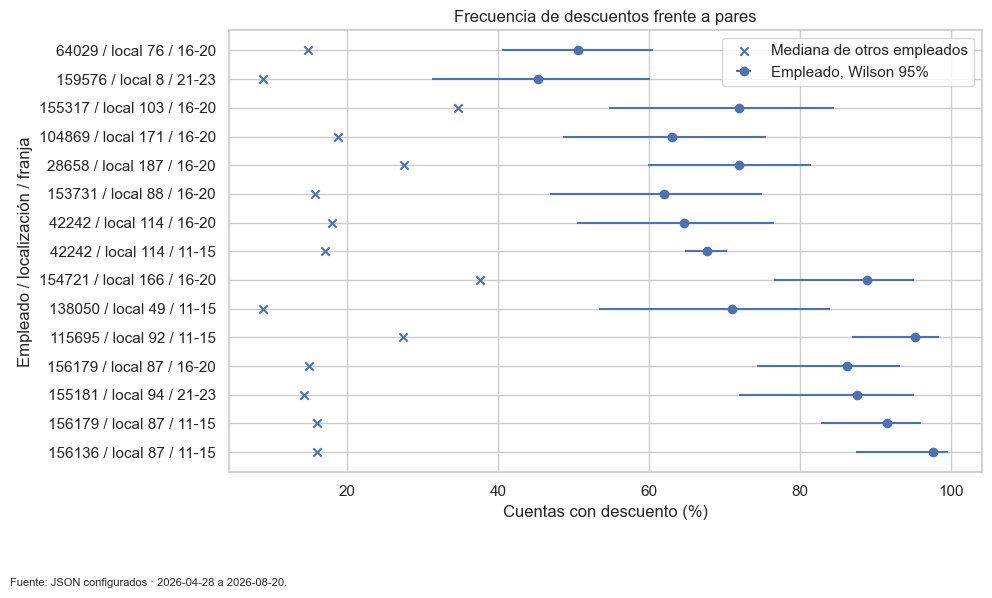

Aplicadores y gerentes tienen conteos separados. Sin actividad total de autorizaciones no se inventa una tasa de aprobación.


In [15]:
sellers = seller_contexts(con, config)
roles = actor_roles(con)
display(sellers.head(25))
display(roles.head(20))
if not sellers.empty:
    print("Contextos con muestra limitada:", int(sellers.limited_sample.sum()))
    print("Señales de tasa elevada respecto de pares:", int(sellers.review_signal.sum()))
    plot = sellers[sellers.peer_median_rate.notna()].head(15).copy()
    if not plot.empty:
        plot["label"] = plot.seller_id+" / local "+plot.location_id+" / "+plot.time_band
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.errorbar(plot.discount_rate*100, np.arange(len(plot)),
                    xerr=np.maximum(0,np.vstack([(plot.discount_rate-plot.wilson_low)*100,
                                    (plot.wilson_high-plot.discount_rate)*100])), fmt="o", label="Empleado, Wilson 95%")
        ax.scatter(plot.peer_median_rate*100,np.arange(len(plot)),marker="x",label="Mediana de otros empleados")
        ax.set_yticks(np.arange(len(plot)),plot.label)
        ax.legend()
        finish_plot(ax,"Frecuencia de descuentos frente a pares","Cuentas con descuento (%)","Empleado / localización / franja")
print("Aplicadores y gerentes tienen conteos separados. Sin actividad total de autorizaciones no se inventa una tasa de aprobación.")


## 4. ¿Qué empleados y gerentes concentran descuentos?

Se analizan registros positivos, pares empleado–gerente y cuentas distintas por
localización. Las participaciones se calculan dentro de los descuentos observados;
no representan la probabilidad de que un gerente autorice una petición.
La razón observado/esperado usa los márgenes de registros de la misma localización.
Puede reflejar asignaciones habituales de trabajo; no es evidencia causal de colusión.


,location_id,employee_id,manager_id,pair_checks,positive_records,recorded_amount_provisional,employee_records,manager_records,location_records,employee_share,manager_share,observed_expected_ratio
0,114,42242,66792,460,511,2678.24,1001.0,1025.0,4870.0,0.510490,0.498537,2.425448
1,96,52492,147697,357,392,2388.91,803.0,1483.0,4229.0,0.488169,0.264329,1.392089
2,14,154072,154656,323,355,2257.15,560.0,1368.0,3153.0,0.633929,0.259503,1.461094
3,41,78088,149231,322,377,2864.94,503.0,1030.0,2072.0,0.749503,0.366019,1.507738
4,196,22593,132939,291,334,1728.26,1009.0,1401.0,3301.0,0.331021,0.238401,0.779943
5,19,157712,156971,278,313,3877.29,414.0,981.0,1978.0,0.756039,0.319062,1.524408
6,56,64804,8452,278,326,1751.64,685.0,872.0,2916.0,0.475912,0.373853,1.591469
7,172,110343,153350,262,327,2636.52,780.0,868.0,2156.0,0.419231,0.376728,1.041315
8,172,110343,78855,261,307,2585.39,780.0,804.0,2156.0,0.393590,0.381841,1.055447
9,86,146005,73282,251,297,2837.46,432.0,1374.0,3022.0,0.687500,0.216157,1.512100


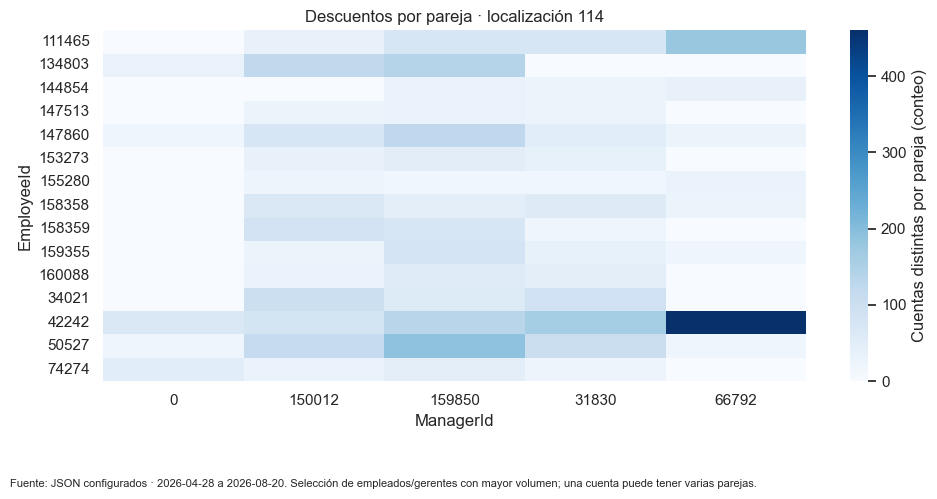

In [16]:
pairs = employee_manager_pairs(con)
display(pairs.head(25))
if not pairs.empty:
    selected_location = pairs.location_id.iloc[0]
    local = pairs[pairs.location_id==selected_location]
    top_employees = local.groupby("employee_id").pair_checks.sum().nlargest(15).index
    top_managers = local.groupby("manager_id").pair_checks.sum().nlargest(10).index
    matrix = local[local.employee_id.isin(top_employees) & local.manager_id.isin(top_managers)].pivot_table(
        index="employee_id", columns="manager_id", values="pair_checks", aggfunc="sum", fill_value=0)
    if not matrix.empty:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.heatmap(matrix,cmap="Blues",ax=ax,cbar_kws={"label": "Cuentas distintas por pareja (conteo)"})
        finish_plot(ax,f"Descuentos por pareja · localización {selected_location}","ManagerId","EmployeeId",
                    "Selección de empleados/gerentes con mayor volumen; una cuenta puede tener varias parejas.")


## 5. ¿Hay cambios persistentes entre abril y agosto?

**Métodos:** tasas semanales y mediana móvil de cuatro semanas consecutivas
observadas. Los huecos interrumpen la ventana; no se rellenan como cero ventas.
Las semanas inicial/final pueden ser parciales: revisa observed_business_days y n.
OpenTime y CloseTime dan contexto, no la hora en que se aplicó el descuento.
Cinco meses permiten explorar patrones semanales, no estacionalidad anual.


,location_id,seller_id,week_start,checks,discounted_checks,discount_rate,observed_business_days,reconciled_checks,discount_to_gross,segment,rolling_median_4_observed_weeks
0,1,101854,2026-05-11,1,0.0,0.000000,1,0,NaN,1,NaN
1,1,101854,2026-05-25,1,0.0,0.000000,1,0,NaN,2,NaN
2,1,101854,2026-07-27,1,1.0,1.000000,1,0,NaN,3,NaN
3,1,138135,2026-04-27,29,4.0,0.137931,2,0,NaN,1,NaN
4,1,138135,2026-05-04,28,7.0,0.250000,2,0,NaN,1,0.193966
5,1,138135,2026-05-11,41,1.0,0.024390,3,0,NaN,1,0.137931
6,1,138135,2026-05-18,61,5.0,0.081967,4,0,NaN,1,0.109949
7,1,138135,2026-05-25,55,6.0,0.109091,4,0,NaN,1,0.095529
8,1,138135,2026-06-01,52,6.0,0.115385,4,0,NaN,1,0.095529
9,1,138135,2026-06-08,53,5.0,0.094340,4,0,NaN,1,0.101715


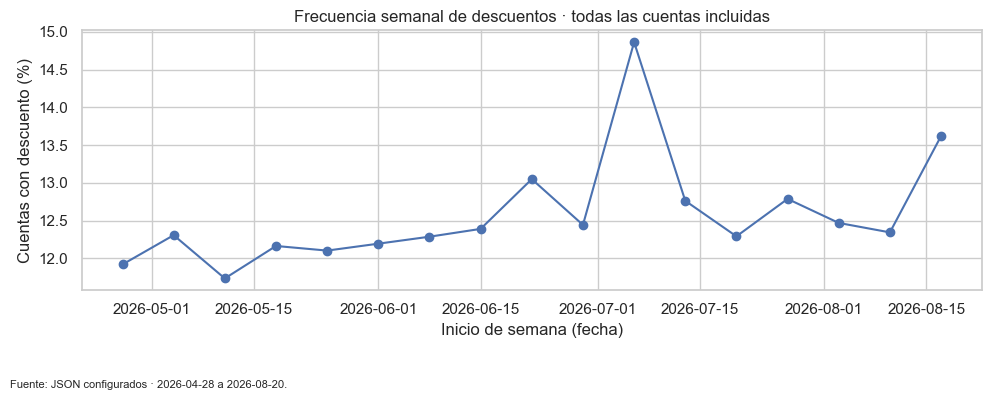

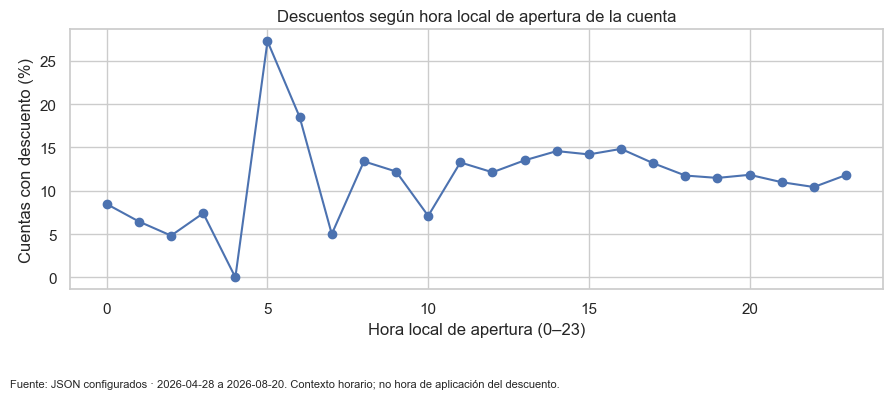

In [17]:
trends = weekly_trends(con)
display(trends.head(20))
weekly_locations = baseline(con,"week_start").sort_values("week_start")
if not weekly_locations.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(weekly_locations.week_start,100*weekly_locations.discount_rate,marker="o")
    finish_plot(ax,"Frecuencia semanal de descuentos · todas las cuentas incluidas","Inicio de semana (fecha)","Cuentas con descuento (%)")
hourly = con.execute("""SELECT open_hour,count(*) checks,avg(has_discount::DOUBLE) discount_rate
    FROM facts WHERE open_hour IS NOT NULL GROUP BY 1 ORDER BY 1""").fetchdf()
if not hourly.empty:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(hourly.open_hour,100*hourly.discount_rate,marker="o")
    finish_plot(ax,"Descuentos según hora local de apertura de la cuenta","Hora local de apertura (0–23)","Cuentas con descuento (%)",
                "Contexto horario; no hora de aplicación del descuento.")


## 6. ¿Qué otras características acompañan los descuentos?

**Métodos:** tasas y diferencias de tasas dentro de localización, centro, franja y
día de semana; conteos de cuentas que contienen categorías de productos.
Una categoría se cuenta una vez por cuenta, aunque haya muchos artículos o modificadores.

`has_cash` identifica pagos de importe positivo cuyo PayCatName, al normalizar
espacios/mayúsculas, es CASH. Una cuenta mixta puede tener efectivo. Revisa los
nombres del proveedor antes de interpretar cuentas sin CASH como otro medio.
Los artículos gratuitos y modificadores no se consideran fraude por sí solos.


In [18]:
related = associations(con)
display(related["cash_void"].head(20))
display(related["payment_rate_differences"].head(20))
display(related["categories"].sort_values("checks",ascending=False).head(20))
display(con.execute("""SELECT category_id,category_name,count(*) payment_records,
    count(*) FILTER (WHERE amount<0) negative_records FROM payments
    GROUP BY 1,2 ORDER BY payment_records DESC LIMIT 30""").fetchdf())
if amounts_ready:
    display(con.execute("""SELECT location_id,count(*) full_discount_checks FROM facts
        WHERE money_eligible AND full_discount GROUP BY 1 ORDER BY 2 DESC""").fetchdf())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,location_id,revenue_center_id,time_band,weekday,has_cash,has_void,checks,discounted_checks,discount_rate,full_discount_checks,reconciled_checks
0,67,1,21-23,7,True,False,45,7.0,0.155556,0,0
1,125,1,16-20,7,False,False,925,135.0,0.145946,0,0
2,115,1,11-15,1,False,False,490,95.0,0.193878,0,0
3,137,1,21-23,3,False,False,349,42.0,0.120344,0,0
4,69,1,21-23,5,False,False,366,29.0,0.079235,0,0
5,112,1,21-23,5,False,False,487,40.0,0.082136,0,0
6,115,1,11-15,5,False,False,572,50.0,0.087413,0,0
7,112,1,11-15,6,False,False,487,71.0,0.145791,0,0
8,116,1,16-20,6,False,False,1026,122.0,0.118908,0,0
9,183,1,11-15,6,False,False,472,62.0,0.131356,0,0


,location_id,revenue_center_id,time_band,weekday,checks_no_cash,checks_cash,discount_rate_no_cash,discount_rate_cash,rate_difference_cash_minus_no_cash
0,1,1,00-10,1,5.0,1.0,0.200000,0.000000,-0.200000
1,1,1,00-10,2,4.0,NaN,0.000000,NaN,NaN
2,1,1,00-10,3,4.0,NaN,0.000000,NaN,NaN
3,1,1,00-10,4,10.0,1.0,0.200000,0.000000,-0.200000
4,1,1,00-10,5,15.0,3.0,0.266667,0.000000,-0.266667
5,1,1,00-10,6,11.0,4.0,0.090909,0.250000,0.159091
6,1,1,00-10,7,8.0,4.0,0.250000,0.250000,0.000000
7,1,1,11-15,1,781.0,309.0,0.079385,0.161812,0.082427
8,1,1,11-15,2,704.0,278.0,0.136364,0.140288,0.003924
9,1,1,11-15,3,751.0,328.0,0.114514,0.118902,0.004388


,location_id,revenue_center_id,time_band,major_category_id,major_category_name,sub_category_id,sub_category_name,checks,discounted_checks,discount_rate
46998,87,1,16-20,300,NA BEVERAGE,302,SOFT DRNKS,8951,1460.0,0.163110
67400,87,1,16-20,119,FOOD,281,MODS/MISC,8859,1477.0,0.166723
23445,198,1,16-20,119,FOOD,214,PROMO 1,8313,961.0,0.115602
17641,170,1,11-15,300,NA BEVERAGE,302,SOFT DRNKS,7852,901.0,0.114748
35347,1,1,16-20,300,NA BEVERAGE,302,SOFT DRNKS,7645,954.0,0.124787
58606,1,1,16-20,119,FOOD,281,MODS/MISC,7457,982.0,0.131688
92088,9,1,16-20,300,NA BEVERAGE,302,SOFT DRNKS,7289,708.0,0.097133
7334,198,1,16-20,300,NA BEVERAGE,302,SOFT DRNKS,7178,882.0,0.122875
81871,82,1,16-20,119,FOOD,214,PROMO 1,6947,1093.0,0.157334
2891,87,1,16-20,119,FOOD,220,SIDES,6865,1085.0,0.158048


,category_id,category_name,payment_records,negative_records
0,2,VISA,885871,3
1,1,CASH,486509,12
2,3,MASTERCARD,412939,0
3,27,DOORDASH,197995,0
4,9,GIFT CARD,98762,0
5,28,UBEREATS,47914,0
6,4,DISCOVER,47528,0
7,5,AMEX,35387,0
8,37,GRUBHUB,7020,0
9,14,GC Sold,5871,3764


## 7. ¿Existen combinaciones inusuales de señales?

**ML exploratorio:** Isolation Forest, 200 árboles, semilla 42 y sin fijar una
proporción esperada de fraude. Variables por vendedor–localización–semana:
exceso de frecuencia de descuentos, descuento/venta bruta, anulaciones y efectivo.
Las expectativas proceden de medianas de compañeros por contexto, calculadas
solo con abril–julio y excluyendo al empleado evaluado.

Se requieren al menos 50 observaciones de referencia y cinco vendedores; cada
semana debe tener 30 cuentas, 30 conciliadas y al menos 80% de cobertura de
contextos y de importes. Los contextos de agosto sin pares históricos suficientes
se excluyen, en lugar de asignarles una expectativa cero.

El entrenamiento termina el 31 de julio; agosto solo se puntúa. Las semanas que
cruzan julio/agosto se separan por fecha de cada cuenta. La puntuación y su percentil
frente a la referencia no son probabilidades de fraude. Las señales adjuntas
describen variables observadas; no son una explicación causal del modelo.
Sin suficiente histórico o conciliación, esta sección se omite con un motivo.


In [19]:
model_result = explore_anomalies(con, config)
print(model_result["status"], "·", model_result["message"])
print(model_result["diagnostics"])
if model_result["status"]=="completed":
    display(model_result["candidates"])
    scored = model_result["scored_august"]
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(scored.anomaly_score,bins=20,ax=ax)
    finish_plot(ax,"Puntuaciones de anomalía en agosto","Puntuación Isolation Forest (mayor = más inusual)","Vendedor-semanas (conteo)",
                "Referencia abril–julio; sin etiquetas de fraude.")


skipped · Importes derivados pendientes: selecciona las convenciones después de revisar conciliación.
{}


## Casos para revisión y exportación

Si el modelo pudo puntuar agosto, se seleccionan cuentas de sus 25 vendedor-semanas
más inusuales con descuentos. Si no, se muestran ejemplos priorizados por señales
observables (descuento y anulación, efectivo y múltiples registros), sin fingir una
clasificación de fraude. La lista se limita a 100 cuentas y conserva la procedencia.

Los CSV incluyen calidad, contextos de vendedores, parejas y casos. Los importes
registrados llevan la etiqueta provisional; los derivados solo se usan con
conciliación. Revisa las exclusiones y cobertura antes de generalizar resultados.


In [20]:
candidate_weeks = model_result["candidates"] if model_result["status"]=="completed" else None
cases = review_checks(con,config,sellers=candidate_weeks,limit=100)
display(cases.head(25))
report_dir = export_reports(config,quality,sellers,pairs,cases,model_result)
print("Reportes locales:",report_dir)
print("Conclusiones a completar después de ejecutar con todos los datos:")
print("1. Cobertura y principales límites de calidad.")
print("2. Descuentos habituales y diferencias entre contextos comparables.")
print("3. Casos y preguntas concretas para revisión operativa.")
print("4. Definiciones o políticas que faltan para distinguir descuentos legítimos de abuso.")


,uid,check_id,location_id,business_day,seller_id,seller_count,recorded_amount_provisional,check_discount_records,item_discount_records,has_cash,void_records,duration_minutes,money_eligible,source_file,source_row,observed_signal,interpretation
0,5250fef54fbd5986f023:3205,1317057,32,2026-08-01,156245,1,217.10,0,56,True,6,104.0,False,C:\Shdezg2000\Datasets\Applebee's\facts\facts\...,3205,Descuento y anulación en la misma cuenta,Caso para revisión; importe registrado no equi...
1,914027c5493698d9accf:2840,1454722,33,2026-07-23,161586,1,143.47,0,47,True,12,87.0,False,C:\Shdezg2000\Datasets\Applebee's\facts\facts\...,2840,Descuento y anulación en la misma cuenta,Caso para revisión; importe registrado no equi...
2,5b4a9eefd692421c8f87:11339,1527479,121,2026-08-02,149610,1,163.46,0,39,True,1,278.0,False,C:\Shdezg2000\Datasets\Applebee's\facts\facts\...,11339,Descuento y anulación en la misma cuenta,Caso para revisión; importe registrado no equi...
3,7098537770f517d37a83:9881,1409962,92,2026-07-02,156955,1,20.61,1,33,True,6,67.0,False,C:\Shdezg2000\Datasets\Applebee's\facts\facts\...,9881,Descuentos en ambos niveles; revisar conciliación,Caso para revisión; importe registrado no equi...
4,5b35e5c3e78708e6c3d0:17906,1108423,153,2026-06-12,160432,1,44.48,1,30,True,3,66.0,False,C:\Shdezg2000\Datasets\Applebee's\facts\facts\...,17906,Descuentos en ambos niveles; revisar conciliación,Caso para revisión; importe registrado no equi...
5,cecf48eed2a5fb73d332:10515,975992,84,2026-05-22,159516,1,159.91,2,28,True,5,84.0,False,C:\Shdezg2000\Datasets\Applebee's\facts\facts\...,10515,Descuentos en ambos niveles; revisar conciliación,Caso para revisión; importe registrado no equi...
6,eb106434f07a7bcd7fa7:5477,859670,60,2026-07-26,161002,1,130.40,2,27,True,4,62.0,False,C:\Shdezg2000\Datasets\Applebee's\facts\facts\...,5477,Descuentos en ambos niveles; revisar conciliación,Caso para revisión; importe registrado no equi...
7,94c14da400b9a500a869:11652,1315050,155,2026-08-12,162171,1,66.48,0,28,True,6,170.0,False,C:\Shdezg2000\Datasets\Applebee's\facts\facts\...,11652,Descuento y anulación en la misma cuenta,Caso para revisión; importe registrado no equi...
8,18ccc34f45f0e44a3c55:13949,1749108,137,2026-06-20,152534,1,15.99,0,26,True,1,75.0,False,C:\Shdezg2000\Datasets\Applebee's\facts\facts\...,13949,Descuento y anulación en la misma cuenta,Caso para revisión; importe registrado no equi...
9,0653f91eb0faeeeed6c2:982,2020002,9,2026-05-17,158352,1,60.49,1,24,True,4,115.0,False,C:\Shdezg2000\Datasets\Applebee's\facts\facts\...,982,Descuentos en ambos niveles; revisar conciliación,Caso para revisión; importe registrado no equi...


Reportes locales: c:\Users\shdez\Databricks-Applebees_anomaly_detection\notebooks\outputs\eda\reports
Conclusiones a completar después de ejecutar con todos los datos:
1. Cobertura y principales límites de calidad.
2. Descuentos habituales y diferencias entre contextos comparables.
3. Casos y preguntas concretas para revisión operativa.
4. Definiciones o políticas que faltan para distinguir descuentos legítimos de abuso.


## Referencias y límites

- [DuckDB y Parquet](https://duckdb.org/docs/current/data/parquet/overview).
- [Wilson en statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.stats.proportion.proportion_confint.html).
- [Desviación absoluta mediana en SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.median_abs_deviation.html).
- [Isolation Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html).

Los catálogos son snapshots: Deleted, Borrowed, PrimaryJobID y localización del
empleado pueden no describir su situación en la fecha de una venta. Sin calendario
de turnos, asignaciones, permisos o promociones, quedan factores explicativos sin
observar. No se calculan precisión/recall de fraude ni pérdidas demostradas.
